# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [28]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

Saving cameraman.jpg to cameraman (3).jpg


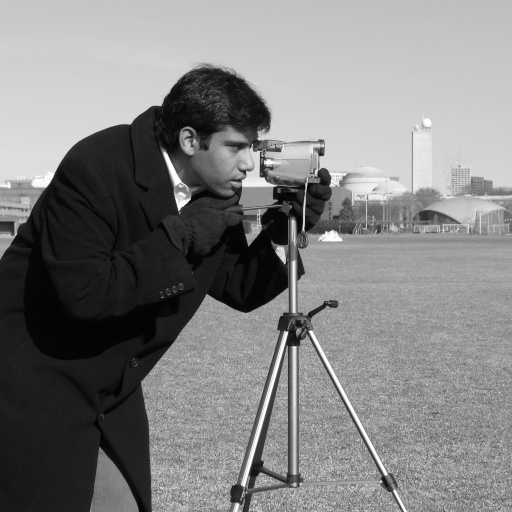

In [29]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg").convert("L")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [30]:
# Get the size of the image
width, height = img.size
print(f"Original size: {width} x {height}")
# scaling factors
scale_x, scale_y = 2, 2

Original size: 512 x 512


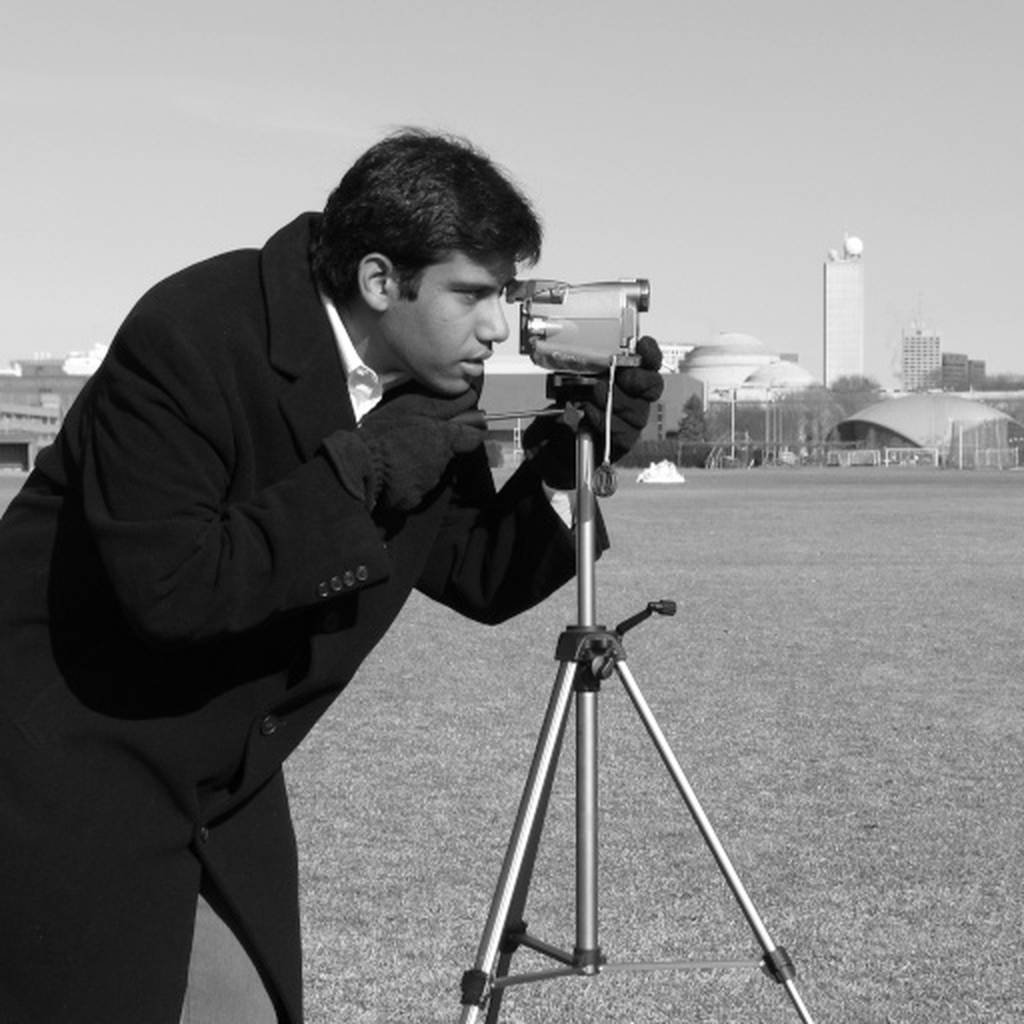

In [31]:
# ── 1. Increase size (scale ×2) ──────────────────────
new_size = (int(width * scale_x), int(height * scale_y))
# Resize the image using PIL's built-in method
scaled_img = img.resize(new_size, resample=Image.LANCZOS)
scaled_img

In [32]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size:   {scaled_img.size}")

Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [33]:
cx, cy = 2, 1
nonuniform_size = (int(width * cx), int(height * cy))
print(f"Non-uniform target size: {nonuniform_size}")

Non-uniform target size: (1024, 512)


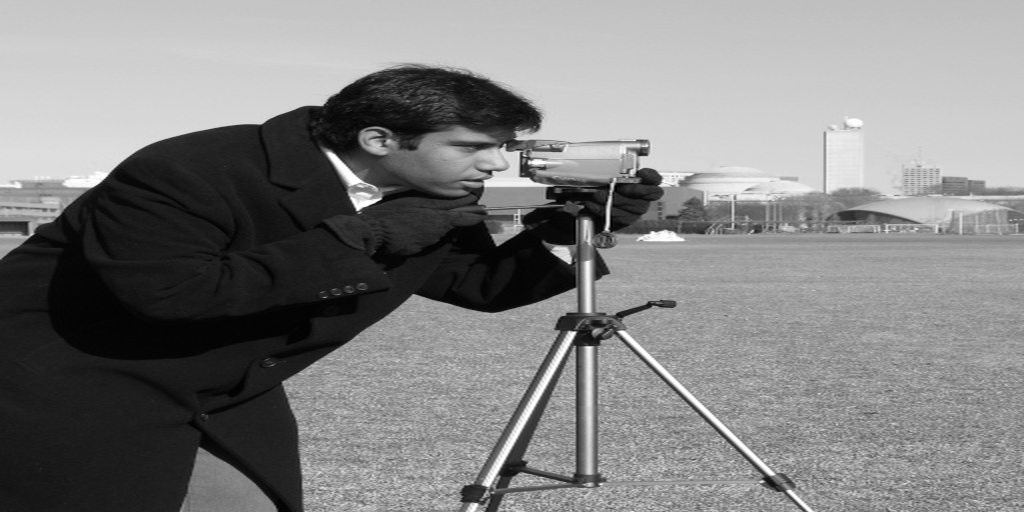

In [34]:
nonuniform_img = img.resize(nonuniform_size, resample=Image.LANCZOS)
nonuniform_img

In [35]:
nonuniform_img.save("task1_1b_nonuniform_scaled.jpg")
print(f"Original size:    {img.size}")
print(f"Non-uniform size: {nonuniform_img.size}")

Original size:    (512, 512)
Non-uniform size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


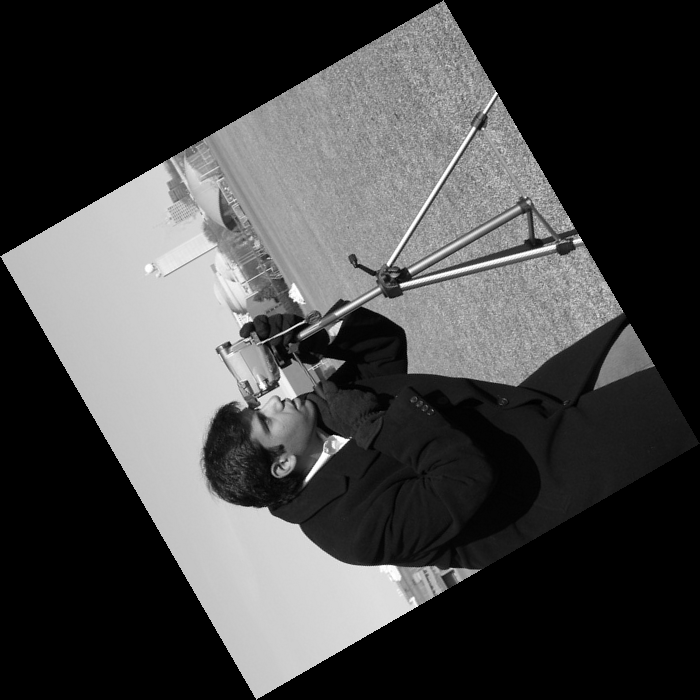

In [36]:
# ── 2. Rotate 120 degrees ──────────────────────
rotated_img = img.rotate(120, expand=True, resample=Image.BICUBIC)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")
print(f"Original size: {img.size}")
print(f"Rotated size:  {rotated_img.size}")
rotated_img

### 3. Shear

In [37]:
# -- c. Get the image dimensions ──────────────────
width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 512, Height: 512


In [38]:
# -- d. define the shear matrix ─────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shx, shy = shear_factor, 0
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)
print(f"New canvas size: {new_width} x {new_height}")

New canvas size: 768 x 512


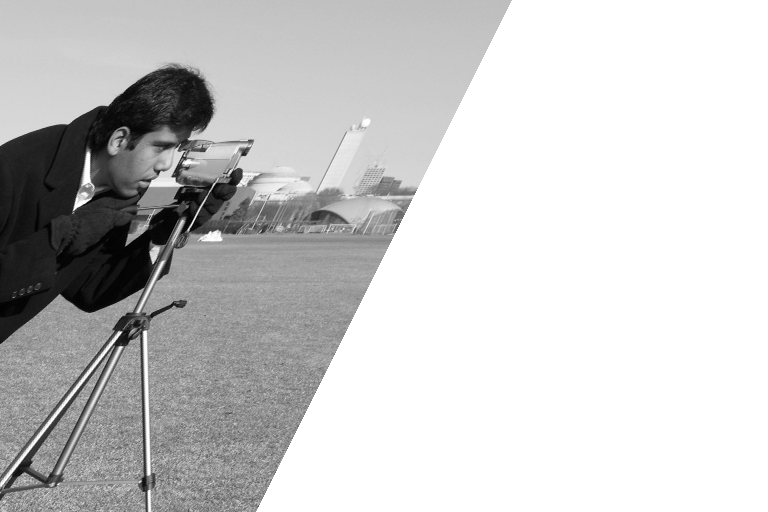

In [39]:
# -- e. Apply the shear transformation to the image ──────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
tx = -shx * height if shx < 0 else 0
ty = -shy * width if shy < 0 else 0
matrix = (1, shx, tx, shy, 1, ty)
sheared_img = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC,
    fillcolor=255
)
sheared_img

In [40]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print(f"Original size: {img.size}")
print(f"Sheared size:  {sheared_img.size}")

Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

**Experiment notes:**

- Increasing the shear factor from 0.1 → 0.8 increases the horizontal slant, and the canvas grows wider each time to avoid clipping the image.
- Switching to a Y-axis shear (`shx = 0`, `shy = factor`) tilts the image vertically instead of horizontally.
- Combining X and Y shear (both `shx` and `shy` non-zero) slants the image diagonally in both directions at once.


# Intensity Transformations
Negative · Log · Power Law (Gamma)

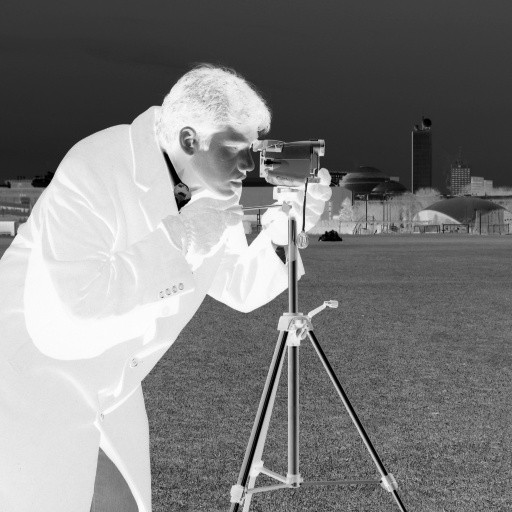

In [41]:
# ── 1. Negative ──────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img_np = Image.fromarray(negative_arr.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np

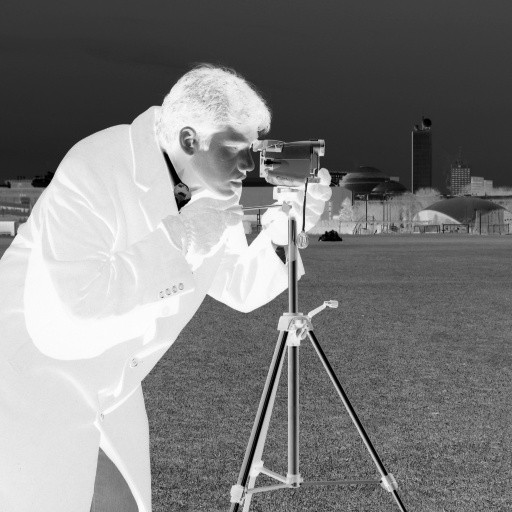

In [42]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)
negative_img_pil.save("task2_1_negative_pil.jpg")
negative_img_pil

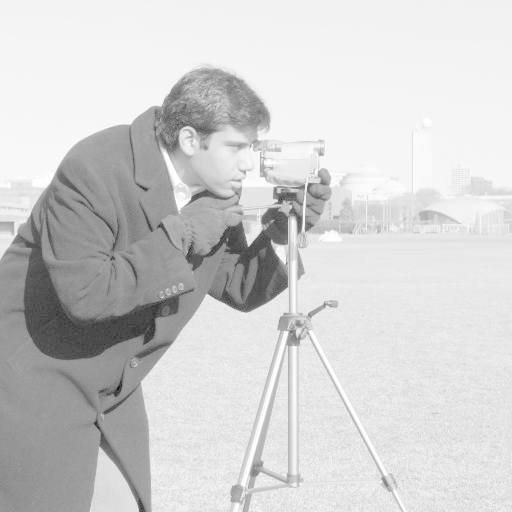

In [43]:
# ── 2. Log transformation ──────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)
# Apply the log transformation to each pixel
arr_float = np.array(img, dtype=np.float64)
log_transformed_arr = c * np.log(1 + arr_float)
log_img = Image.fromarray(np.uint8(log_transformed_arr))
log_img.save("task2_2_log.jpg")
log_img

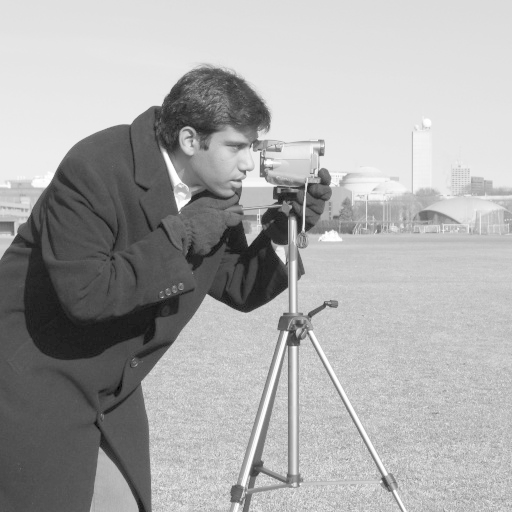

In [44]:
# ── 3. Power-law / Gamma correction ───────────
gamma = 0.5
arr_norm = np.array(img, dtype=np.float64) / 255.0
gamma_corrected = np.power(arr_norm, gamma)
gamma_img = Image.fromarray(np.uint8(gamma_corrected * 255))
gamma_img.save("task2_3_gamma.jpg")
gamma_img